# QAOA for Max-Cut with CUDA-Q

## 1. Imports and Global Settings

In [1]:
import numpy as np
import cudaq
from cudaq import spin
from typing import List

cudaq.set_target("nvidia")
cudaq.set_random_seed(13)
np.random.seed(13)

## 2. Define Graph

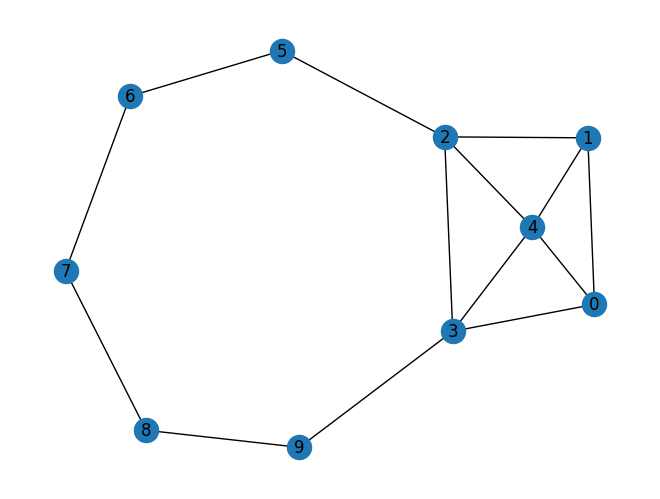

In [2]:

nodes = list(range(10))

edges = [
    [0,1],[1,2],[2,3],[3,0],
    [4,0],[4,1],[4,2],[4,3],
    [5,6],[6,7],[7,8],[8,9],
    [2,5],[3,9]
]
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
nx.draw(G, with_labels=True)
plt.savefig("graph.png")
plt.show()

edges_src = [e[0] for e in edges]
edges_tgt = [e[1] for e in edges]


## Defining qubit and parameters

In [3]:
qubit_count = len(nodes)
layer_count = 5
parameter_count = 2 * layer_count

## 3. Cost Function & Ising Hamiltonian

In [4]:
def hamiltonian_max_cut(edges_src, edges_tgt):
    H = 0
    for u,v in zip(edges_src, edges_tgt):
        H += 0.5 * (spin.z(u) * spin.z(v) - spin.i(u) * spin.i(v))
    return H

hamiltonian = hamiltonian_max_cut(edges_src, edges_tgt)
hamiltonian


## 4. Problem Unitary (Trotterized Evolution)

In [5]:

@cudaq.kernel
def qaoa_problem(qubit_0: cudaq.qubit, qubit_1: cudaq.qubit, gamma: float):
    x.ctrl(qubit_0, qubit_1)
    rz(2.0 * gamma, qubit_1)
    x.ctrl(qubit_0, qubit_1)


## 5. Full QAOA Circuit

In [6]:

@cudaq.kernel
def qaoa_kernel(qubit_count:int, layer_count:int, edges_src:List[int], edges_tgt:List[int], thetas:List[float]):
    qreg = cudaq.qvector(qubit_count)
    h(qreg)

    for i in range(layer_count):
        # Cost unitary
        for e in range(len(edges_src)):
            qaoa_problem(qreg[edges_src[e]], qreg[edges_tgt[e]], thetas[i])
        # Mixer
        for q in range(qubit_count):
            rx(2.0 * thetas[i + layer_count], qreg[q])


## 6. Objective Function

In [7]:

def objective(parameters):
    return cudaq.observe(
        qaoa_kernel, hamiltonian,
        qubit_count, layer_count, edges_src, edges_tgt, parameters
    ).expectation()


## 7. Classical Optimization

In [8]:

optimizer = cudaq.optimizers.COBYLA()
optimizer.initial_parameters = np.random.uniform(-1,1,parameter_count)

opt_val, opt_params = optimizer.optimize(
    dimensions=parameter_count,
    function=objective
)

print("Optimal expectation:", opt_val)
print("Estimated MaxCut:", -opt_val)
print("Optimal parameters:", opt_params)


Optimal expectation: -10.116036912058384
Estimated MaxCut: 10.116036912058384
Optimal parameters: [1.8782231585484963, 1.2963449237261904, -0.22414926956925077, 0.1105565619475417, -1.5480097282199212, -1.2505649728409949, 2.1848326872294073, 2.472105478330235, -2.0053877857968287, 1.3011939181425032]


## 8. Sampling the Optimal Circuit

In [9]:

counts = cudaq.sample(
    qaoa_kernel, qubit_count, layer_count,
    edges_src, edges_tgt, opt_params
)

best_bitstring = max(counts, key=lambda x: counts[x])
print("Most likely solution:", best_bitstring)


Most likely solution: 1000110101


## 9. Plotting Graph Cut

Cuts: 11



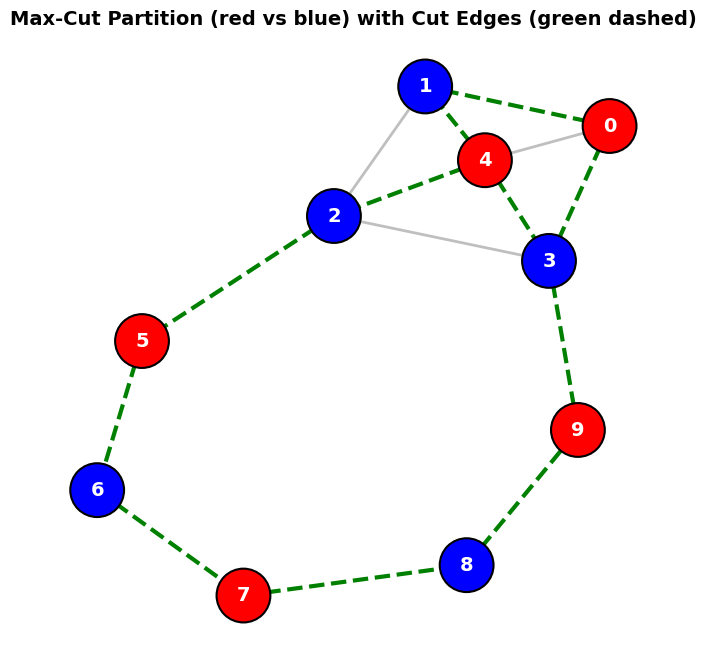

In [10]:
partition = best_bitstring

# Map partition string to colors
color_map = ["red" if partition[i] == "1" else "blue" for i in nodes]

# --- Identify cut edges (edges crossing partitions) ---
cut_edges = []
same_edges = []
for u, v in edges:
    if partition[u] != partition[v]:
        cut_edges.append((u, v))
    else:
        same_edges.append((u, v))

print(f"Cuts: {len(cut_edges)}\n")
# --- Draw the graph ---
pos = nx.spring_layout(G, seed=42, k=0.5)

plt.figure(figsize=(8, 8))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=color_map,
    edgecolors="black",
    node_size=1500,
    linewidths=1.5
)

# Draw edges inside partitions (gray)
nx.draw_networkx_edges(G, pos, edgelist=same_edges, width=2, edge_color="gray", alpha=0.5)

# Draw cut edges (highlighted)
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, width=3, edge_color="green", style="dashed")

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=14, font_color="white", font_weight="bold")

plt.title("Max-Cut Partition (red vs blue) with Cut Edges (green dashed)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.savefig("plot.png")